<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_11_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №11. Колебания цилиндрической мембраны (функции Бесселя)

**Задача.** Найти закон колебаний круглой (цилиндрической) мембраны радиуса `R`
и высоты `h`, используя разложение по функциям Бесселя первого рода:

начальное отклонение `φ(r) = 100*J0(μ01*r/R)`, начальная форма по высоте
`φ(z) = sin(π*(z+h)/8)`.

Нужно вычислить корни функции Бесселя (`scipy.special.jn_zeros`), собственные функции
и собственные значения `λ_km`, найти коэффициенты разложения `C_km` (двумерный ряд
Фурье-Бесселя) и построить итоговое решение `u(r,z,t)`.


Вычисляем коэффициенты C_km...
Коэффициенты готовы!


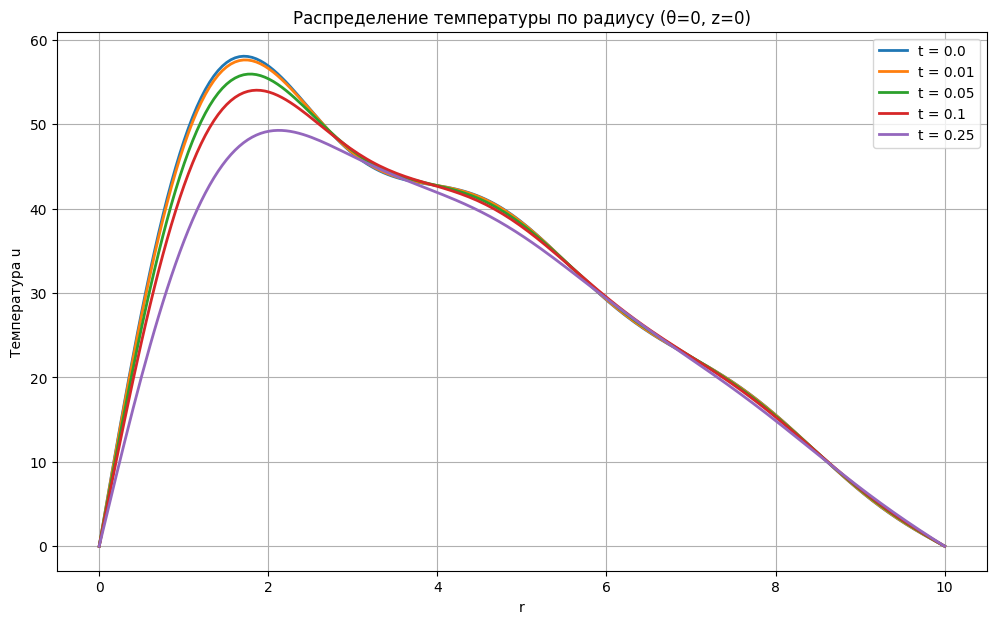

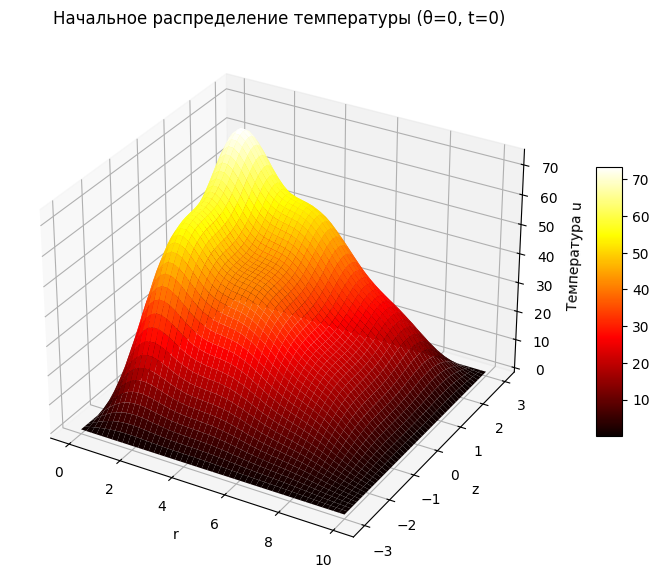

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jn_zeros, j0
from scipy.integrate import quad
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ========== Параметры задачи ==========
R = 10.0
h = 3.0
a = 1.0
mu01 = 2.4048

N_k = 6   # количество радиальных мод
N_m = 4   # количество вертикальных мод

mu_k1 = jn_zeros(1, N_k)   # корни J1

# ========== Начальное условие ==========
def phi_r(r):
    return 100 * j0(mu01 * r / R)

def phi_z(z):
    return np.sin(np.pi * (z + h) / 8.0)

# ========== Собственные функции ==========
def eigen_r(r, k):
    return jv(1, mu_k1[k-1] * r / R)

def eigen_z(z, m):
    return np.sin(m * np.pi * (z + h) / (2 * h))

# ========== Собственные значения ==========
def lambda_km(k, m):
    term_r = (mu_k1[k-1] / R)**2      # <--- исправлено!
    term_z = (m * np.pi / (2 * h))**2
    return np.sqrt(term_r + term_z)

# ========== Вычисление коэффициентов C_km ==========
def compute_Ckm():
    C = np.zeros((N_k, N_m))
    norm_z = h
    print('Вычисляем коэффициенты C_km...')
    for k in range(N_k):
        I_r, _ = quad(lambda r: r * eigen_r(r, k+1) * phi_r(r), 0, R)
        norm_r_val, _ = quad(lambda r: r * eigen_r(r, k+1)**2, 0, R)
        for m in range(N_m):
            I_z, _ = quad(lambda z: phi_z(z) * eigen_z(z, m+1), -h, h)
            C[k, m] = (2.0 / np.pi) * (I_r / norm_r_val) * (I_z / norm_z)
    print('Коэффициенты готовы!')
    return C

C_km = compute_Ckm()

# ========== Решение ==========
def u_solution(r, theta, z, t):
    u = np.zeros_like(r, dtype=float)
    for k in range(N_k):
        for m in range(N_m):
            coeff = C_km[k, m]
            if abs(coeff) < 1e-8:
                continue
            radial = eigen_r(r, k+1)
            axial = eigen_z(z, m+1)
            lam = lambda_km(k+1, m+1)
            time_factor = np.exp(-a**2 * lam**2 * t)   # <--- исправлено
            u += coeff * radial * np.cos(theta) * axial * time_factor
    return u

# ========== 1. Плоские графики для разных t ==========
times = [0.0, 0.01, 0.05, 0.1, 0.25]
r_plot = np.linspace(0, R, 200)

plt.figure(figsize=(12, 7))
for t_val in times:
    u_r = u_solution(r_plot, 0.0, 0.0, t_val)
    plt.plot(r_plot, u_r, linewidth=2, label=f't = {t_val}')

plt.xlabel('r')
plt.ylabel('Температура u')
plt.title('Распределение температуры по радиусу (θ=0, z=0)')
plt.grid(True)
plt.legend()
plt.show()

# ========== 2. Трёхмерный график (t=0, θ=0) ==========
r_3d = np.linspace(0, R, 50)
z_3d = np.linspace(-h, h, 50)
Rg, Zg = np.meshgrid(r_3d, z_3d)
U0 = np.zeros_like(Rg)

for i in range(len(r_3d)):
    for j in range(len(z_3d)):
        U0[j, i] = u_solution(r_3d[i], 0.0, z_3d[j], 0.0)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Rg, Zg, U0, cmap='hot', edgecolor='none')
ax.set_xlabel('r')
ax.set_ylabel('z')
ax.set_zlabel('Температура u')
ax.set_title('Начальное распределение температуры (θ=0, t=0)')
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()


Вычисляем коэффициенты C_km...
Коэффициенты готовы!


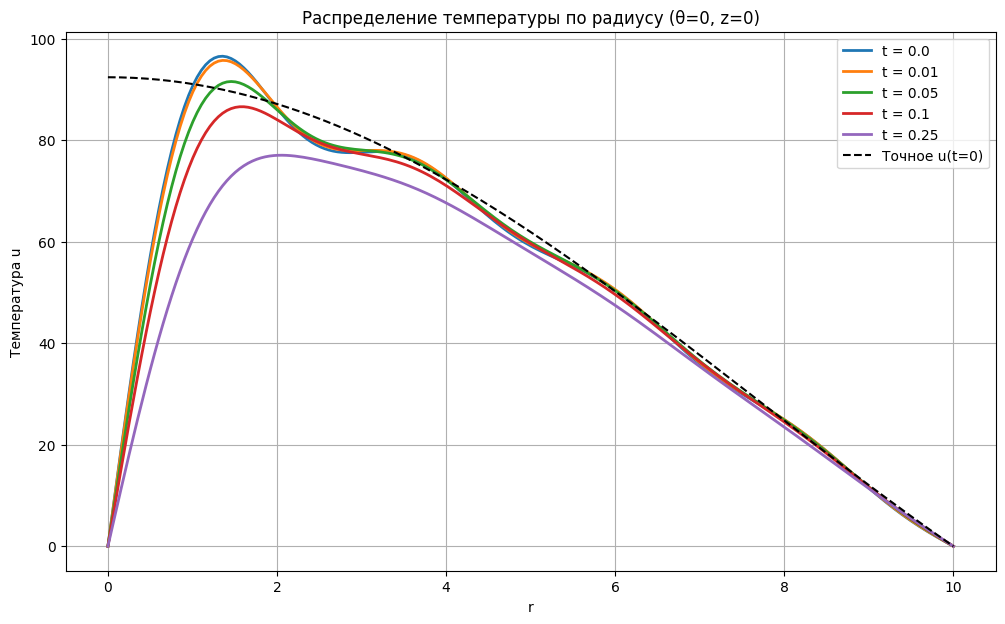

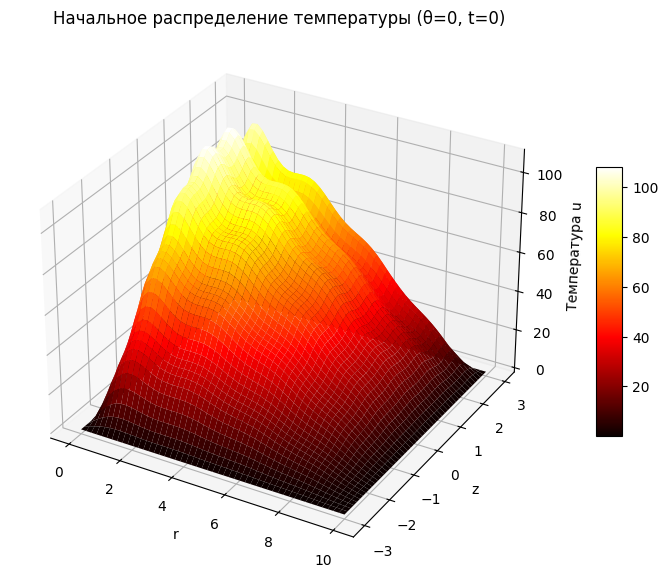

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jn_zeros, j0
from scipy.integrate import quad
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

R = 10.0
h = 3.0
a = 1.0
mu01 = 2.4048

N_k = 8      # можно увеличить
N_m = 12     # увеличено для лучшего приближения по z

mu_k1 = jn_zeros(1, N_k)

def phi_r(r):
    return 100 * j0(mu01 * r / R)

def phi_z(z):
    return np.sin(np.pi * (z + h) / 8.0)   # как в задании

def eigen_r(r, k):
    return jv(1, mu_k1[k-1] * r / R)

def eigen_z(z, m):
    return np.sin(m * np.pi * (z + h) / (2 * h))

def lambda_km(k, m):
    term_r = (mu_k1[k-1] / R) ** 2
    term_z = (m * np.pi / (2 * h)) ** 2
    return np.sqrt(term_r + term_z)

def compute_Ckm():
    C = np.zeros((N_k, N_m))
    norm_z = h
    print('Вычисляем коэффициенты C_km...')
    for k in range(N_k):
        I_r, _ = quad(lambda r: r * eigen_r(r, k+1) * phi_r(r), 0, R)
        norm_r_val, _ = quad(lambda r: r * eigen_r(r, k+1)**2, 0, R)
        for m in range(N_m):
            I_z, _ = quad(lambda z: phi_z(z) * eigen_z(z, m+1), -h, h)
            C[k, m] = (I_r / norm_r_val) * (I_z / norm_z)   # УБРАЛИ 2/π
    print('Коэффициенты готовы!')
    return C

C_km = compute_Ckm()

def u_solution(r, theta, z, t):
    r = np.asarray(r, dtype=float)
    u = np.zeros_like(r)
    for k in range(N_k):
        for m in range(N_m):
            coeff = C_km[k, m]
            if abs(coeff) < 1e-10:
                continue
            radial = eigen_r(r, k+1)
            axial = eigen_z(z, m+1)
            lam = lambda_km(k+1, m+1)
            time_factor = np.exp(-a**2 * lam**2 * t)
            u += coeff * radial * np.cos(theta) * axial * time_factor
    return u

# Графики (как у вас, без изменений)
times = [0.0, 0.01, 0.05, 0.1, 0.25]
r_plot = np.linspace(0, R, 200)

plt.figure(figsize=(12, 7))
for t_val in times:
    u_r = u_solution(r_plot, 0.0, 0.0, t_val)
    plt.plot(r_plot, u_r, linewidth=2, label=f't = {t_val}')

# Проверка: точное начальное условие (при t=0, z=0)
u_exact = phi_r(r_plot) * np.cos(0.0) * phi_z(0.0)
plt.plot(r_plot, u_exact, 'k--', linewidth=1.5, label='Точное u(t=0)')

plt.xlabel('r')
plt.ylabel('Температура u')
plt.title('Распределение температуры по радиусу (θ=0, z=0)')
plt.grid(True)
plt.legend()
plt.show()

# Трёхмерный график (как у вас)
r_3d = np.linspace(0, R, 50)
z_3d = np.linspace(-h, h, 50)
Rg, Zg = np.meshgrid(r_3d, z_3d)
U0 = np.zeros_like(Rg)
for i in range(len(r_3d)):
    for j in range(len(z_3d)):
        U0[j, i] = u_solution(r_3d[i], 0.0, z_3d[j], 0.0)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Rg, Zg, U0, cmap='hot', edgecolor='none')
ax.set_xlabel('r')
ax.set_ylabel('z')
ax.set_zlabel('Температура u')
ax.set_title('Начальное распределение температуры (θ=0, t=0)')
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()